# Week 3

As explained in in class during Lecture 1, each week of this class is an Jupyter notebook like this one. In order to follow the class, you simply start reading from the top, following the instructions.

## Today

This lecture covers:

1. **A short intro lecture**: A video covering key concepts like metadata, Simpson's paradox, and exploratory vs. explanatory analysis.
2. **Conditional plots**: We'll combine crime categories with police district data to uncover geographic patterns — and see how those patterns change over time.
3. **Why visualization matters**: Through a famous example, you'll see why summary statistics alone can be dangerously misleading.
4. **Fundamentals of data visualization**: A deeper dive into visualization theory — histograms, CDFs, KDEs, and more.
5. **Hands-on visualization**: You'll recreate classic plot types (jitter plots, histograms, KDEs, probability plots, box plots) using the SF crime data.

## Part 1: A little intro lecture

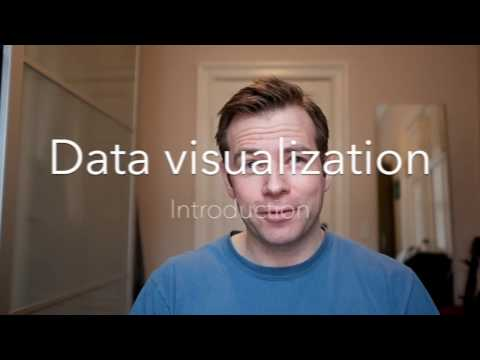

In [1]:
from IPython.display import YouTubeVideo
YouTubeVideo('9D2aI30AMhM', width=800, height=450)

> *Exercise 1.1:* Questions for the lecture. 
> 
> * What is the difference between *data* and *metadata*? How does that relate to the GPS tracks-example?
>   * In the GPS track example data is the actual coordinates or altitude over time. Metadata is the tags that are used in the datafile to section it like "\<TAGS\>".
> * In the video I argue that the human eye is a great tool for data analysis. Do you agree? Explain why/why not. Mention something that the human eye is very good at. Can you think of something that [is difficult for the human eye](http://cdn.ebaumsworld.com/mediaFiles/picture/718392/84732652.jpg). Explain why your example is difficult. 
>   * One case where the human eye struggles is for plots where the scale of an axis is not the best. For example a too big of a scale could make disappear trends in crime data for a type of crime that is less frequent that another but still has fluctuations over time.
> * Simpson's paradox is hard to explain. Come up with your own example - or find one online. Now think about the SF crime data: could Simpson's paradox show up there? Come up with an example.
>   * Drug A being less effective generally than Drug B, but in reality it's more effective in each subgroup (age, or sex for example). For the case of SF crime data the paradox could appear in a similar way, for example: crimes are becoming less frequent in the city but in a particular neighborhood crime rates are increasing.
> * In your own words, explain the difference between *exploratory* and *explanatory* data analysis. Think about the plots you made in Weeks 1 and 2. They were exploratory ... we were trying to understand the dataset. But could they also be explanatory? Which ones would you highlight if you were trying to explain the dataset so someone who wasn't taking the course? Which ones did not give you any information? (I'm not asking you to answer those questions in great detail, I just want you to think through your work and start your brains processing ... pretty soon you WILL have to choose which plots are most useful to explain aspects of the data.)
>   * Exploratory data analysis tries to identify patterns, trends or hidden insights while explanatory data analysis aims to show off the result of the exploration in a nice, concise and scientific way. Many of the plots we have done in the past two weeks are both good to perform exploration and show via explanation. It all really depends if/how we are selecting the data to be shown. One of the plots I liked the least is the polar view of the hourly crime over the 24 hrs because I think it's better visualized in a standard bar plot.

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> Answer in your own words based on the video, don't use your LLM. Once you've written down your answers, it's OK to use the LLM to refine your writing (although, TBH I prefer that you don't ... reading too much LLM text feels generic and boring). 
</div>

## Part 2: The power of conditional plots

We continue working with the merged crime dataset you built in Week 2. The next thing we'll be looking into is how crimes break down across the 10 districts in San Francisco.

> *Exercise 2.1:* The types of crime and how they take place across San Francisco's police districts.
>  
>  * So now we'll be combining information about the police district and crime category columns to explore differences between SF's neighborhoods. First, simply list the names of SF's 10 police districts.
>  * Which has the most total crimes? Which has the most of your Personal Focus Crimes (from Week 2)?
>      * The `larceny theft` category has the most crimes in both total count and personal focus crimes.  
>  * Next, we want to generate a slightly more complicated graphic. I'm interested to know if there are certain crimes that happen much more in certain neighborhoods than what's typical. Below I describe how to get that plot going:
>    - First, we need to calculate the relative probabilities of seeing each type of crime in the dataset as a whole. Let's call it `P(crime)`.
>    - Next, we calculate that same probability distribution _but for each PD district_, let's call that `P(crime|district)`. **Note**: In an ideal world, you would normalize according to all crime-types, but it's OK to stay within your nice cleaned dataset and just normalize relative to your Personal Focus Crimes.
>    - Now we look at the ratio `P(crime|district)/P(crime)`. That ratio is equal to 1 if the crime occurs at the same level within a district as in the city as a whole. If it's greater than one, it means that the crime occurs _more frequently_ within that district. If it's smaller than one, it means that the crime is _rarer within the district in question_ than in the city as a whole.
>    - For each district plot these ratios for your Personal Focus Crimes. 
>    - Comment on the top crimes in _Tenderloin_, _Mission_, and _Richmond_. Does this fit with the impression you get of these neighborhoods on Wikipedia (or from your LLM's description of those neighborhoods)?
>       - _Tenderloin_: Neighborhood in downtown, the area has a reputation for crime, homelessness, and open-air drug markets. It is the center of the fentanyl crisis in San Francisco. High in Warrant and disorderly conduct, which makes sense for the high drug usage in the area. There are also other crimes like robbery prostitution and assault. _Mission_: Latin american neighborhood with famous night life. Many crimes are related to prostitution and alcohol usage, which makes sense from the rich night life present. _Richmond_: rich neighborhood in the northwest, many high middle class people live there and there is a tendency for thefts of different types. Probability due to the nicer homes and cars that are around the area. 
>    - Was there a district whose crime profile surprised you — one that didn't match your expectations? What did you expect, and what did the data show?
>       - I was surprised by the high rate of `missing person` in the _Park_ neighborhood, but after a quick online search it seems there has been a recent increase of cases of missing person reported in the Park District.
>    - Do any of your ratios look suspiciously extreme? What happens to the ratio for a rare crime in a small district? How many incidents would you want before trusting the ratio?
>       - Yes. A few stand out as extreme: e.g. _Mission_ and prostitution, _Bayview_ and arson, _Park_ and missing person, and _Tenderloin_ with warrant. For rare crimes in small districts, ratios become unstable so one extra incident can change the ratio a lot.
>    - The ratios tell you the *shape* of each district's crime profile, but not the *scale*. Pick the district with the lowest total crime count — is its ratio plot noisier than the others? What does this tell you about interpreting ratios without also considering volume?
>       - The district with the lowest total focus-crime count is _Park_. Its ratio profile is indeed somewhat spiky (missing person), but it is not the noisiest district overall. _Tenderloin_ and _Bayview_ have higher overall deviation from 1, and _Mission_ has the most extreme single-category spike. This shows that ratio plots capture profile shape but can be misleading without scale: extreme ratios may come from true concentration effects, low counts, or both. Therefore, ratios should always be interpreted together with raw incident counts and ideally uncertainty estimates.
>    - What neighborhood would you prefer to live in? Explain why? 
>       - I would personally choose _Richmond_ because it looks safer than the others and I would install a good alarm system and cameras around my house to avoid being robbed.
>    - BONUS QUESTION. Can you get your LLM to discuss the graphic you created? (E.g. by showing it the image) Did it notice anything you didn't?
>       - No, not really. 

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> See if you can do this on your own — the calculations are fairly simple. If you get stuck, ask your LLM for advice, but don't use it to simply generate the plots. Use it as a help to get hints at how to solve the things you can't figure out on your own — that's how you get familiar with how the Python Libraries actually works.
</div>

**Comment**. Notice how much awesome data science (i.e. learning about interesting real-world crime patterns) we can get out by simply counting and plotting (and looking at ratios). Pretty great, right? 

In [ ]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import re

In [102]:
df = pd.read_csv(os.path.join(os.getcwd(), '..', 'files', 'Merged_Police_Incidents_2003_to_Present.csv'))
# df.head()

In [11]:
PD = df['Police District'].unique()
PD = [x for x in PD if not pd.isna(x) and x != "out of sf"]
print(PD)

['mission', 'taraval', 'southern', 'bayview', 'northern', 'tenderloin', 'central', 'ingleside', 'richmond', 'park']


In [12]:
FOCUS_CRIMES = ["assault", "arson", "burglary", "embezzlement", "fraud", "gambling", 
                      "liquor laws", "missing person", "non-criminal", 
                      "prostitution", "recovered vehicle", "robbery", "stolen property", 
                      "suicide", "suspicious occ", "disorderly conduct", "motor vehicle theft", 
                      "larceny theft", "warrant", "forgery and counterfeiting"]
FOCUS_CRIMES_MINUS_NONCRIMINAL = [crime for crime in FOCUS_CRIMES if crime != "non-criminal"]

In [16]:
data_all = df['Incident Category'].value_counts()
print(data_all)
data_focus = df[df['Mapped Category'].isin(FOCUS_CRIMES_MINUS_NONCRIMINAL)]
print("\n\n")
print(data_focus['Mapped Category'].value_counts())


Incident Category
larceny/theft                 450957
larceny theft                 250788
non-criminal                  189339
assault                       173399
burglary                      121931
vehicle theft                  97259
suspicious occ                 83040
robbery                        62738
warrants                       62105
fraud                          51574
missing person                 48086
motor vehicle theft            37833
recovered vehicle              20839
forgery/counterfeiting         18124
disorderly conduct             14889
warrant                        11978
prostitution                   11639
stolen property                 5956
arson                           5452
embezzlement                    3312
forgery and counterfeiting      2227
liquor laws                     1627
suicide                         1587
gambling                         264
Name: count, dtype: int64



Mapped Category
larceny theft                 701745
assault     

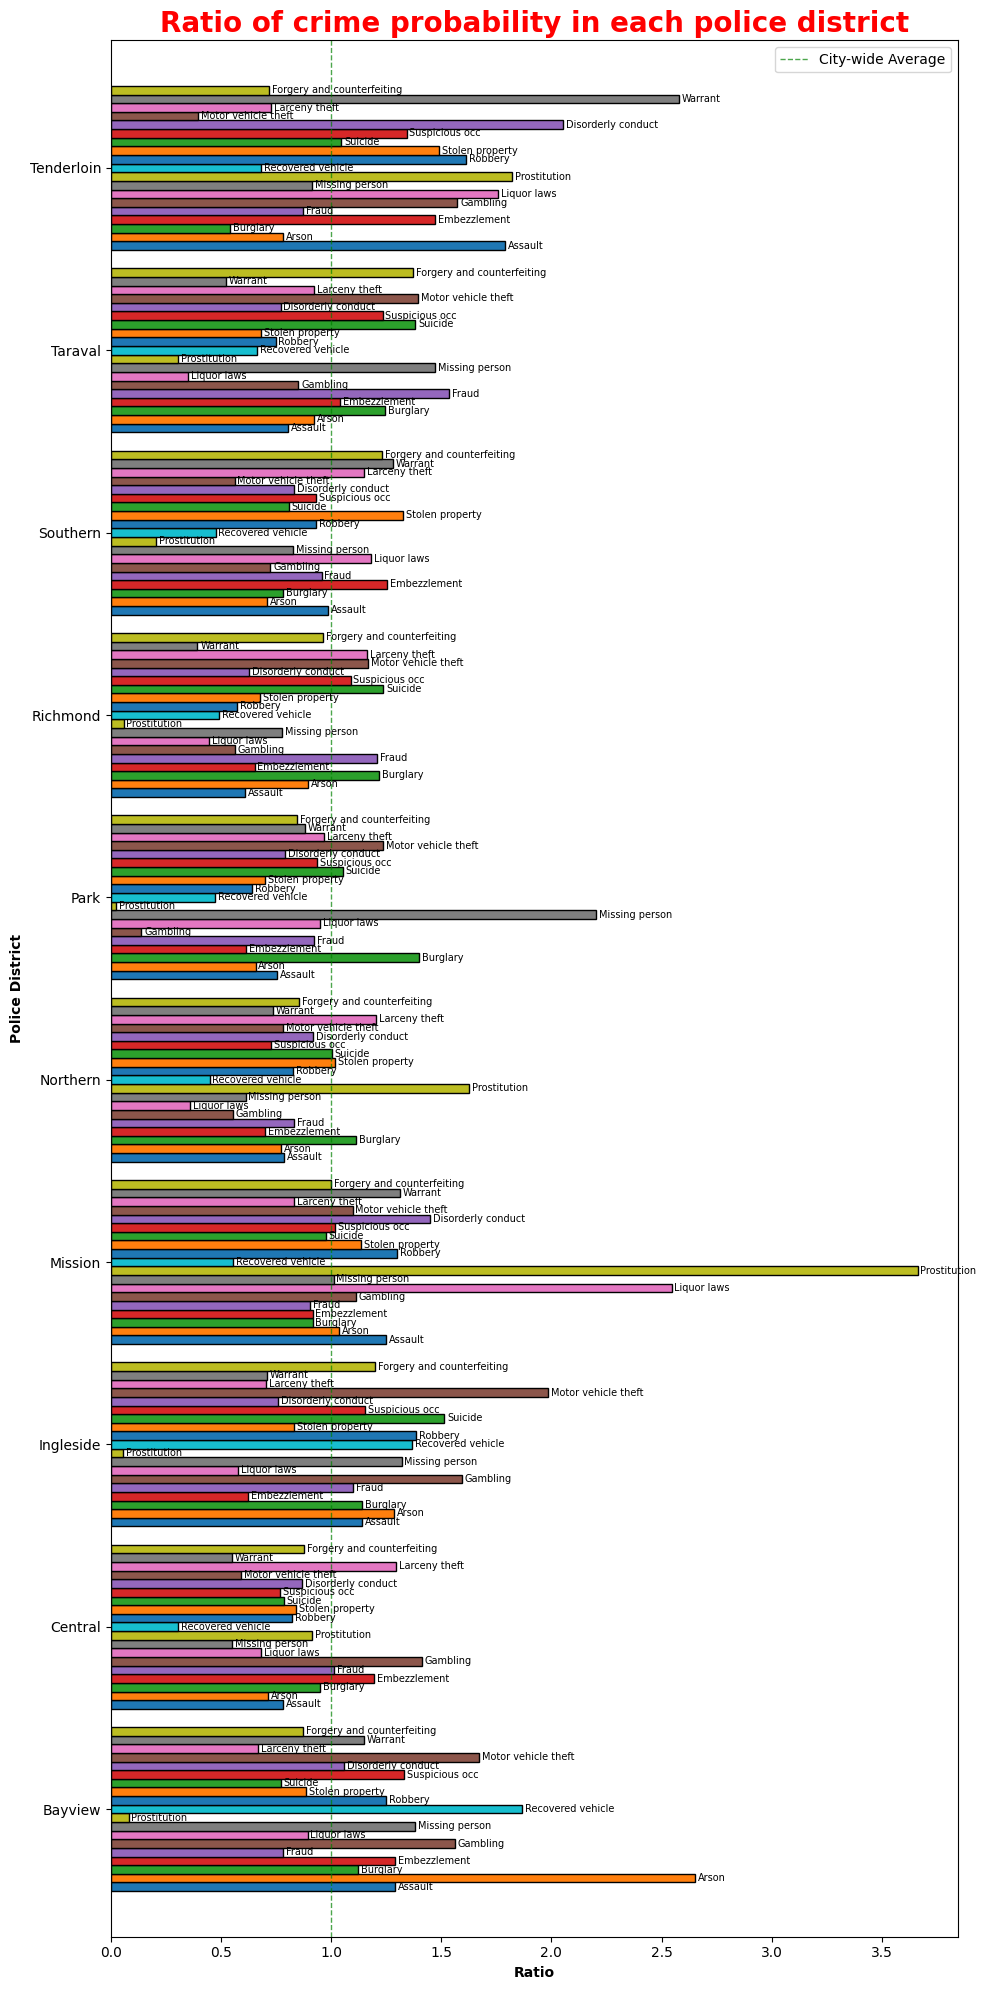

In [51]:
P_crime = (
    data_focus["Mapped Category"]
    .value_counts(normalize=True)
    .reindex(FOCUS_CRIMES_MINUS_NONCRIMINAL, fill_value=0)
)
P_crime_district = (
    data_focus.groupby("Police District")["Mapped Category"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
    .reindex(columns=FOCUS_CRIMES_MINUS_NONCRIMINAL, fill_value=0)
)
ratios = P_crime_district.div(P_crime, axis=1)
# remove 'out of sf' and NaN police districts'
ratios = ratios.loc[ratios.index.notna() & (ratios.index != "out of sf")]


ratios_plot = ratios.copy()
ratios_plot.index = ratios_plot.index.str.title()
ax = ratios_plot.plot(
    kind="barh",
    figsize=(10, 20),
    width=0.9,
    edgecolor="black",
    legend=False
)
for container in ax.containers:
    crime_name = container.get_label().capitalize()
    ax.bar_label(
        container,
        labels=[crime_name] * len(container),
        fontsize=7,
        padding=2
    )
vline = ax.axvline(
    x=1,
    color="green",
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="City-wide Average"
)
ax.legend(handles=[vline], loc="upper right")
plt.title("Ratio of crime probability in each police district", fontsize=20, fontweight="bold", color="red")
plt.xlabel("Ratio", fontweight="bold")
plt.ylabel("Police District", fontweight="bold")
plt.tight_layout()
plt.show()

> *Exercise 2.2:* How do crime patterns across districts change over time?
>
> In Exercise 2.1 you computed `P(crime|district)/P(crime)` across the entire dataset. But San Francisco has changed a lot between 2003 and 2025. Have the crime profiles of its neighborhoods changed too?
>
> * Split your merged dataset into two periods: **early** (2003–2008) and **late** (2020–2025). Recompute the `P(crime|district)/P(crime)` ratios for each period separately.
> * Create a side-by-side visualization: for each district, show the ratios from the early period next to the ratios from the late period. (A grouped bar chart works well here.)
> * Which district changed the most? Which crime type shifted the most across districts? How do you even define "changed the most"? See if you can come up with a single number that summarizes how much a district's crime profile shifted between the two periods. (Idea: think about the ratio vectors as points in space.)
>   * The district that changed the most just by looking at the plot is _Tenderloin_, that is also proven by the L2 distance between the ratio vectors that reports a value of 5.8. Similar usage of the ration vector can give us insights about the type of crime that shifted the most across districts, I computed the L2 change across district and the mean absolute change. Both metrics return similar results, with gambling, prostitution and liquor laws at the top  
> * Pick one or two striking changes and try to explain them. Think about what you know (or can find out) about how San Francisco's neighborhoods have evolved — gentrification, policy changes, the opioid crisis, etc.
>   * A clear change is in _Tenderloin_ where categories linked to common crimes (notably gambling, prostitution, warrants) move a lot from early to late period. A possible explanation is a mix from the opioid-crisis, changes in residents type, and possibly a higher concentration of police dispatched in the area that alters the amounts of reported crimes.
> * Connecting back to Week 1: if a predictive policing algorithm had been trained on the early period, how well would its assumptions hold in the late period? What does this tell you about the shelf life of models trained on historical crime data?
>   * The assumptions would hold poorly because data and cities are a non stationary concept that evolves over time. This implies that models for predictive policing have a short shelf life.

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> The data wrangling and plotting are fair game for LLM help - it will help speed you up, but check for errors! The interpretation and the connection to predictive policing should be your own thinking.
</div>

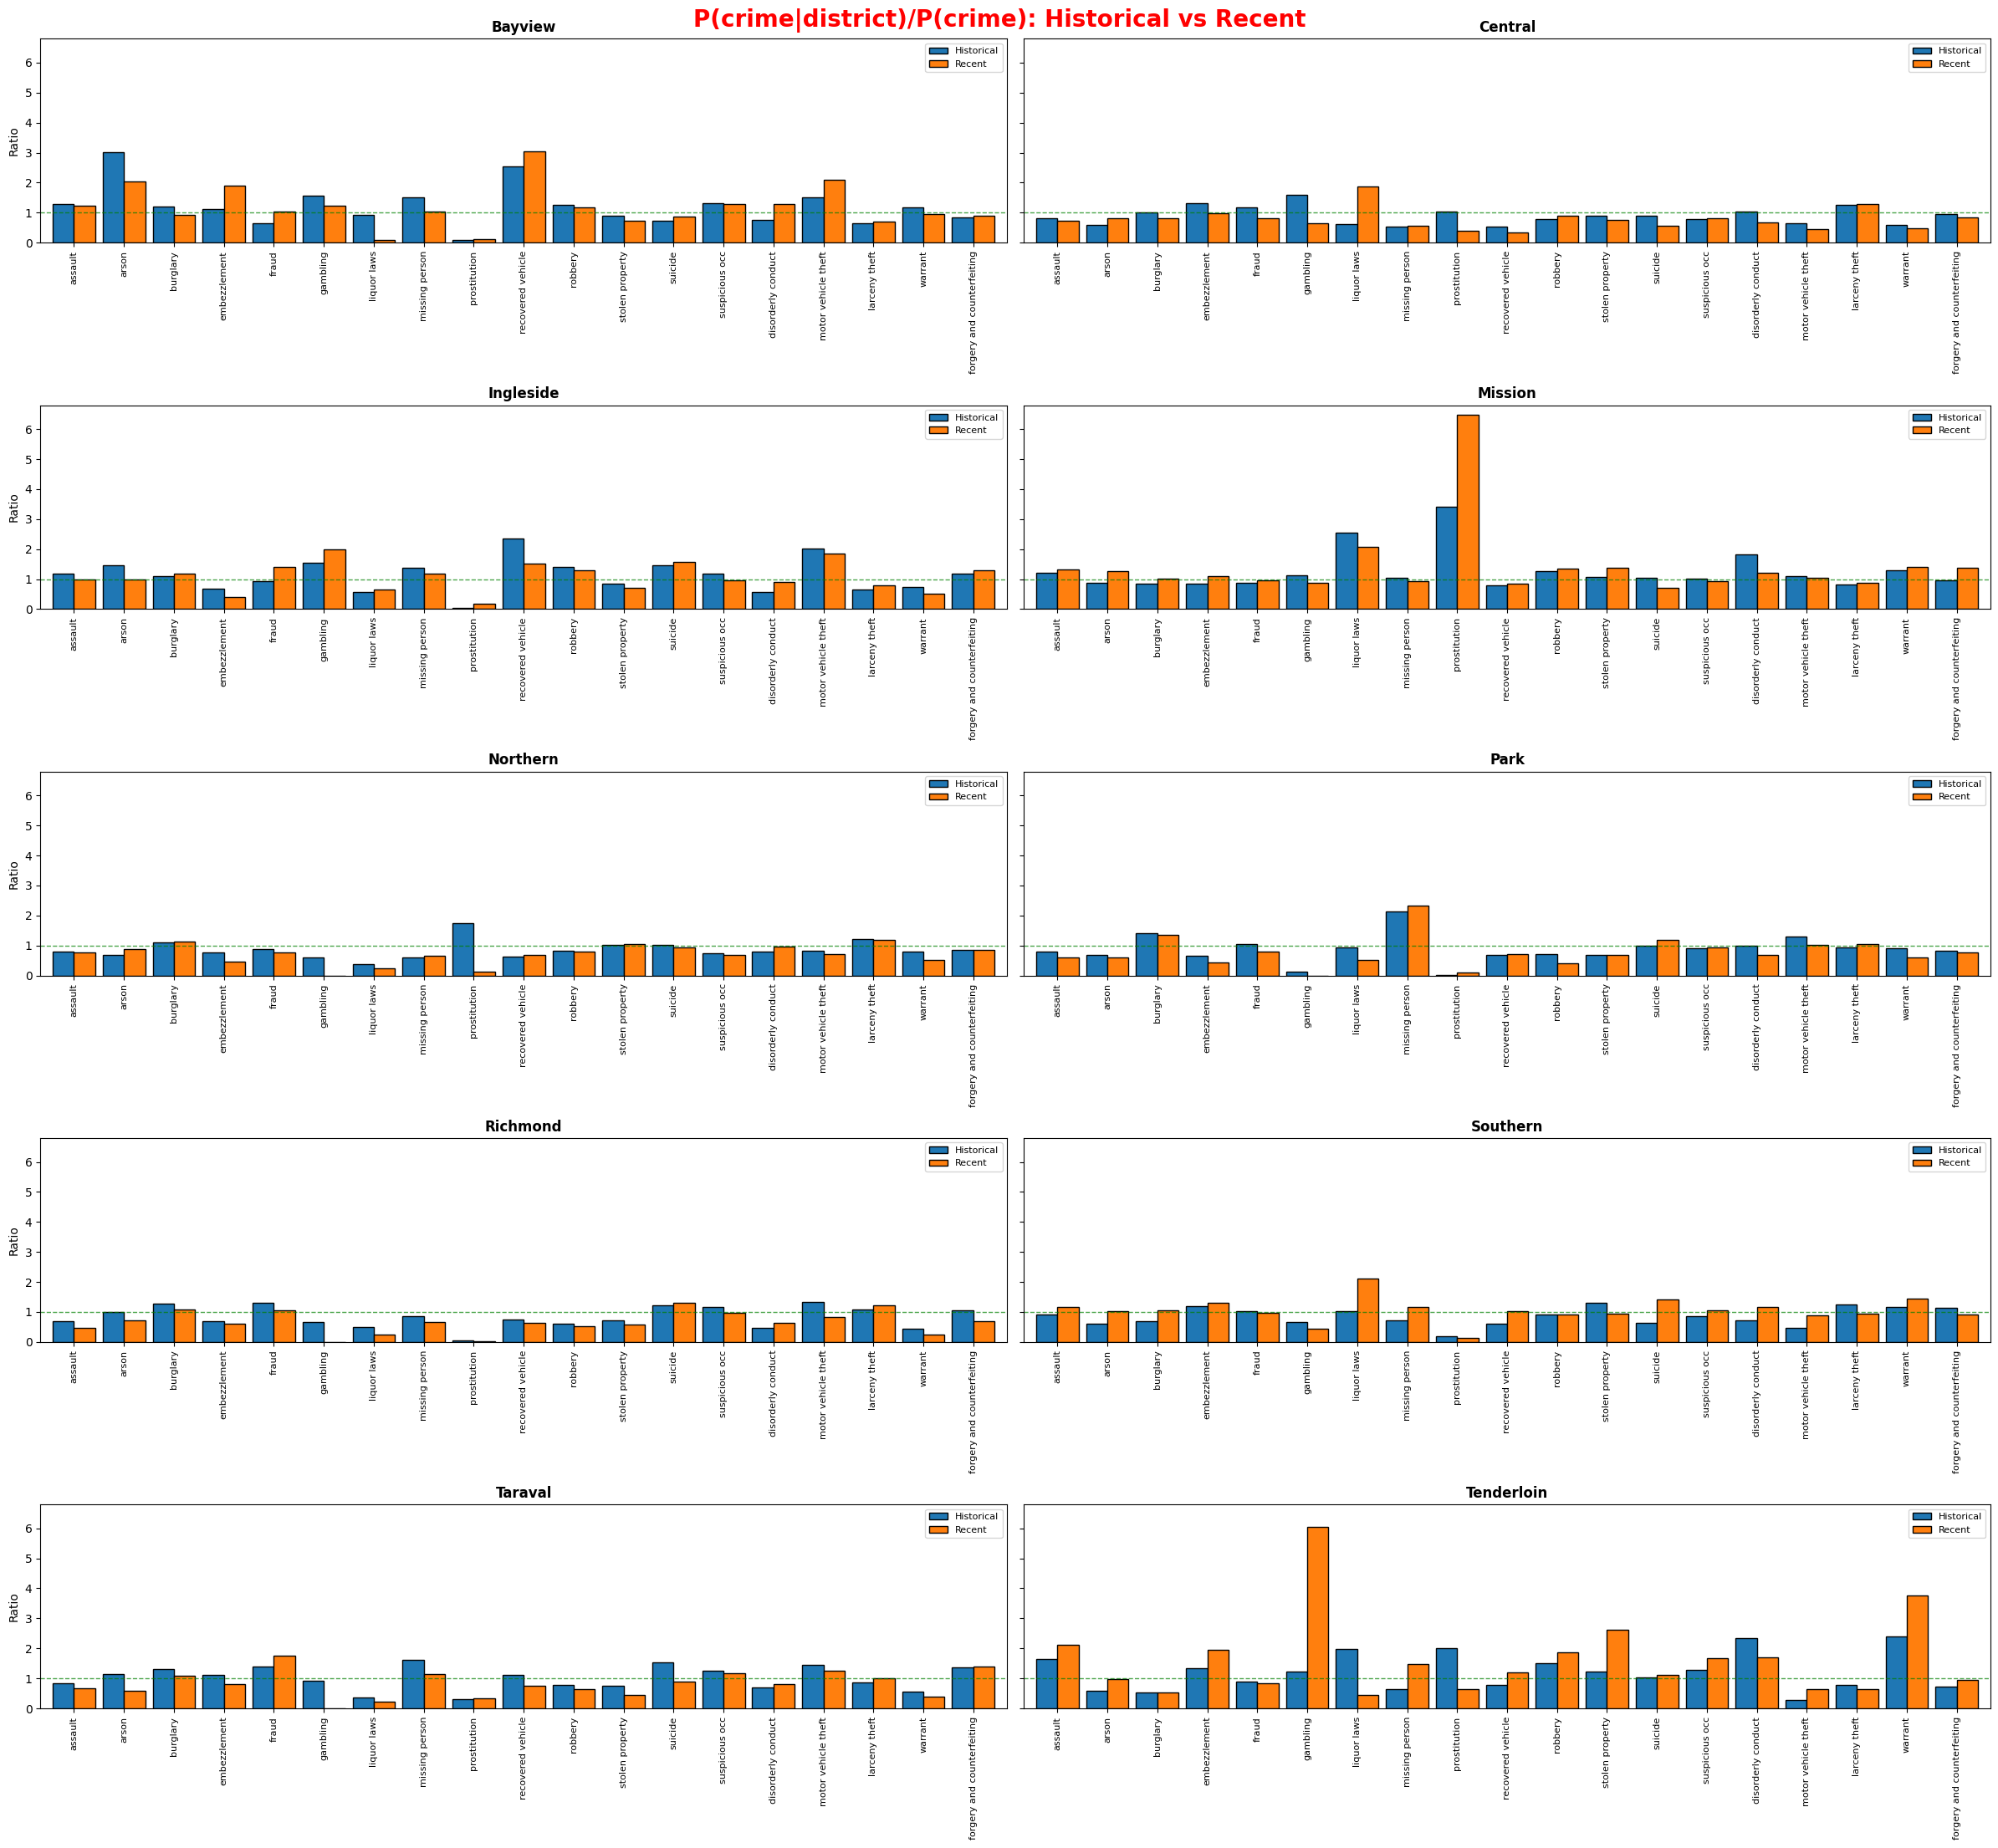

District shift score (L2, higher = changed more):
Police District
tenderloin    5.805109
mission       3.269089
bayview       1.956899
central       1.921563
northern      1.816930
southern      1.810003
taraval       1.563188
ingleside     1.363824
richmond      1.154245
park          0.889009
dtype: float64

Crime shift score across districts (mean |delta|, higher = changed more):
Mapped Category
gambling                      0.935009
prostitution                  0.706173
liquor laws                   0.624787
arson                         0.397292
disorderly conduct            0.364579
embezzlement                  0.331038
warrant                       0.325179
recovered vehicle             0.300406
stolen property               0.300045
missing person                0.294782
motor vehicle theft           0.283693
suicide                       0.281405
fraud                         0.241865
assault                       0.180578
forgery and counterfeiting    0.159877
burglary     

In [62]:
df_period = df[
    df["Mapped Category"].isin(FOCUS_CRIMES_MINUS_NONCRIMINAL)
    & df["Police District"].notna()
    & (df["Police District"] != "out of sf")
    & df["Dataset"].isin(["Historical", "Recent"])
].copy()

def compute_ratio_table(df_in, period_label):
    d = df_in[df_in["Dataset"] == period_label]
    # P(crime)
    p_crime = (
        d["Mapped Category"]
        .value_counts(normalize=True)
        .reindex(FOCUS_CRIMES_MINUS_NONCRIMINAL, fill_value=0)
    )
    # P(crime|district)
    p_crime_district = (
        d.groupby("Police District")["Mapped Category"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(columns=FOCUS_CRIMES_MINUS_NONCRIMINAL, fill_value=0)
    )
    # ratio = P(crime|district)/P(crime)
    ratios = p_crime_district.div(p_crime.replace(0, np.nan), axis=1)
    ratios = ratios.replace([np.inf, -np.inf], np.nan).fillna(0)
    return ratios

ratios_hist = compute_ratio_table(df_period, "Historical")
ratios_recent = compute_ratio_table(df_period, "Recent")

# align districts/columns across periods
all_districts = sorted(set(ratios_hist.index).union(set(ratios_recent.index)))
ratios_hist = ratios_hist.reindex(index=all_districts, columns=FOCUS_CRIMES_MINUS_NONCRIMINAL, fill_value=0)
ratios_recent = ratios_recent.reindex(index=all_districts, columns=FOCUS_CRIMES_MINUS_NONCRIMINAL, fill_value=0)

n = len(all_districts)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(24, 4.5 * nrows), sharey=True)
axes = np.array(axes).reshape(-1)
for i, district in enumerate(all_districts):
    ax = axes[i]
    compare = pd.DataFrame({
        "Historical": ratios_hist.loc[district],
        "Recent": ratios_recent.loc[district]
    })
    compare.plot(kind="bar", ax=ax, width=0.85, edgecolor="black")
    ax.axhline(1, color="green", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_title(district.title(), fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Ratio")
    ax.tick_params(axis="x", rotation=90, labelsize=8)
    ax.legend(loc="upper right", fontsize=8)
fig.suptitle("P(crime|district)/P(crime): Historical vs Recent", fontsize=20, fontweight="bold", color="red")
plt.tight_layout()
plt.show()

# metrics: find delta
delta = ratios_recent - ratios_hist
# single-number district shift: L2 distance between ratio vectors
district_shift_l2 = np.sqrt((delta ** 2).sum(axis=1)).sort_values(ascending=False)

# crime shift across districts: mean absolute change + L2 across districts
crime_shift_mean_abs = delta.abs().mean(axis=0).sort_values(ascending=False)
crime_shift_l2 = np.sqrt((delta ** 2).sum(axis=0)).sort_values(ascending=False)

print("District shift score (L2, higher = changed more):")
print(district_shift_l2)

print("\nCrime shift score across districts (mean |delta|, higher = changed more):")
print(crime_shift_mean_abs)

print("\nCrime shift score across districts (L2, higher = changed more):")
print(crime_shift_l2)

print(f"\nMost changed district (L2): {district_shift_l2.index[0]}  | score={district_shift_l2.iloc[0]:.3f}")
print(f"Most shifted crime (mean |delta|): {crime_shift_mean_abs.index[0]}  | score={crime_shift_mean_abs.iloc[0]:.3f}")

## Part 3: A little visualization exercise

We will now leave the SF crime data for a little bit. So before we continue with geographic analysis in the coming weeks, let's explore a fundamental lesson about *why* visualization matters — and why summary statistics alone can be dangerously misleading. This connects directly to our work so far: we've been computing ratios and averages of crime data to compare districts, but could we have gotten away with just looking at the numbers? What if the numbers look the same but the data looks completely different?

Start by downloading these four datasets: [Data 1](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/data1.tsv), [Data 2](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/data2.tsv), [Data 3](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/data3.tsv), and [Data 4](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/data4.tsv). The format is `.tsv`, which stands for _tab separated values_. 
As you will later realize, these are famous datasets!
Each file has two columns (separated using the tab character). The first column is $x$-values, and the second column is $y$-values.  

It's ok to just download these files to disk by right-clicking on each one, but if you use Python and `urllib` or `urllib2` to get them, I'll really be impressed. You can also go "the old way" and use _stackoverflow_. And by the way, never search stack overflow: search Google and choose the relevant stackoverflow topic.

Now, to the exercise:

> *Exercise 3.1:* 
> 
> * Using the `numpy` function `mean`, calculate the mean of both $x$-values and $y$-values for each dataset. 
>      * Use python string formatting to print precisely two decimal places of these results to the output cell. Check out [this _stackoverflow_ page](http://stackoverflow.com/questions/8885663/how-to-format-a-floating-number-to-fixed-width-in-python) for help with the string formatting.
> * Now calculate the variance for all of the various sets of $x$- and $y$-values, by using the `numpy` function `var`. Print it to three decimal places.
> * Use `numpy` to calculate the [Pearson correlation](https://en.wikipedia.org/wiki/Pearson_product-moment_correlation_coefficient) between $x$- and $y$-values for all four data sets (also print to three decimal places).
> * The next step is use _linear regression_ to fit a straight line $f(x) = a x + b$ through each dataset and report $a$ and $b$ (to two decimal places). An easy way to fit a straight line in Python is using `scipy`'s `linregress`. It works like this
> ```
> from scipy import stats
> a, b, r_value, p_value, std_err = stats.linregress(x,y)
>```
> * Comment on the results from the previous steps. What do you observe? 
>   * Just by looking at the computed statistics the 4 datasets seem very similar almost identical.
> * Finally, it's time to plot the four datasets using `matplotlib.pyplot`. Use a two-by-two [`subplot`](http://matplotlib.org/examples/pylab_examples/subplot_demo.html) to put all of the plots nicely in a grid and use the same $x$ and $y$ range for all four plots. And include the linear fit in all four plots. (To get a sense of what I think the plot should look like, you can take a look at my version [here](https://raw.githubusercontent.com/suneman/socialdata2026/main/files/anscombe.png).)
> * Explain - in your own words - what you think my point with this exercise is (see below for tips on this).
>   * The point is to never just aggregate data in summary statistics, but always plot and see the underlying structure of them.
> * Think about the crime data: we've been computing means and counts across districts and years. Can you think of a situation in your own analysis where two groups might have the same average but look very different when plotted?
>   * Two districts with a similar average ration or crime average could look very dissimilar in a plot. One might have crimes across the whole district while one might have spikes in one or a couple of roads. 
> * What did you get out of asking the LLM about the previous sub-question? How did you even go about asking the LLM about the point of the entire set of questions? Reflect on whether or not the LLM helped you get smarter? Did the LLM spoil the punchline? Would you have learned more if you hadn't asked it?
>   * The LLM helped with phrasing my ideas correctly and helped with making the 2x2 grid of plots. I did not ask theoretical questions so I have not extracted knowledge from it. Just used for the sake of quick formatting my text and making the plot.

<div class="alert alert-block alert-info">
<b>LLM guidance:</b> For the calculations and plotting, try to write the code yourself first — if you get stuck, ask your LLM for help with specific functions, but don't ask it for the full solution. For the final interpretation question, write down your own thoughts first, then you can ask the LLM for additional insight afterward.
</div>

Get more insight in the ideas behind this exercise by reading [here](https://en.wikipedia.org/wiki/Anscombe%27s_quartet). Here you can also get an explanation of why the datasets are actually famous - I mean they have their own Wikipedia page!!

If you enjoyed Anscombe's quartet, look up the [Datasaurus Dozen](https://www.research.autodesk.com/publications/same-stats-different-graphs/) — a modern extension where wildly different scatterplots (including a dinosaur!) share the same summary statistics. What does it add to the lesson of Anscombe's quartet? It just adds different patterns but the takeaways remain the same. 

In [76]:
def load_tsv_as_two_arrays(filename):
    path = os.path.join(os.getcwd(), '..', 'files', filename)
    x, y = np.loadtxt(path, delimiter='\t', unpack=True)
    return np.array([x, y])

dataset_1 = load_tsv_as_two_arrays('data1.tsv')
dataset_2 = load_tsv_as_two_arrays('data2.tsv')
dataset_3 = load_tsv_as_two_arrays('data3.tsv')
dataset_4 = load_tsv_as_two_arrays('data4.tsv')

print(f"Dataset 1: \n mean X={dataset_1[0].mean():.2f}, mean Y={dataset_1[1].mean():.2f}, variance X={dataset_1[0].var():.3f}, variance Y={dataset_1[1].var():.3f}, Pearson correlation={np.corrcoef(dataset_1)[0,1]:.3f}, a={stats.linregress(dataset_1[0], dataset_1[1]).slope:.2f}, b={stats.linregress(dataset_1[0], dataset_1[1]).intercept:.2f}")
print(f"Dataset 2: \n mean X={dataset_2[0].mean():.2f}, mean Y={dataset_2[1].mean():.2f}, variance X={dataset_2[0].var():.3f}, variance Y={dataset_2[1].var():.3f}, Pearson correlation={np.corrcoef(dataset_2)[0,1]:.3f}, a={stats.linregress(dataset_2[0], dataset_2[1]).slope:.2f}, b={stats.linregress(dataset_2[0], dataset_2[1]).intercept:.2f}")
print(f"Dataset 3: \n mean X={dataset_3[0].mean():.2f}, mean Y={dataset_3[1].mean():.2f}, variance X={dataset_3[0].var():.3f}, variance Y={dataset_3[1].var():.3f}, Pearson correlation={np.corrcoef(dataset_3)[0,1]:.3f}, a={stats.linregress(dataset_3[0], dataset_3[1]).slope:.2f}, b={stats.linregress(dataset_3[0], dataset_3[1]).intercept:.2f}")
print(f"Dataset 4: \n mean X={dataset_4[0].mean():.2f}, mean Y={dataset_4[1].mean():.2f}, variance X={dataset_4[0].var():.3f}, variance Y={dataset_4[1].var():.3f}, Pearson correlation={np.corrcoef(dataset_4)[0,1]:.3f}, a={stats.linregress(dataset_4[0], dataset_4[1]).slope:.2f}, b={stats.linregress(dataset_4[0], dataset_4[1]).intercept:.2f}")

Dataset 1: 
 mean X=9.00, mean Y=7.50, variance X=10.000, variance Y=3.752, Pearson correlation=0.816, a=0.50, b=3.00
Dataset 2: 
 mean X=9.00, mean Y=7.50, variance X=10.000, variance Y=3.752, Pearson correlation=0.816, a=0.50, b=3.00
Dataset 3: 
 mean X=9.00, mean Y=7.50, variance X=10.000, variance Y=3.748, Pearson correlation=0.816, a=0.50, b=3.00
Dataset 4: 
 mean X=9.00, mean Y=7.50, variance X=10.000, variance Y=3.748, Pearson correlation=0.817, a=0.50, b=3.00


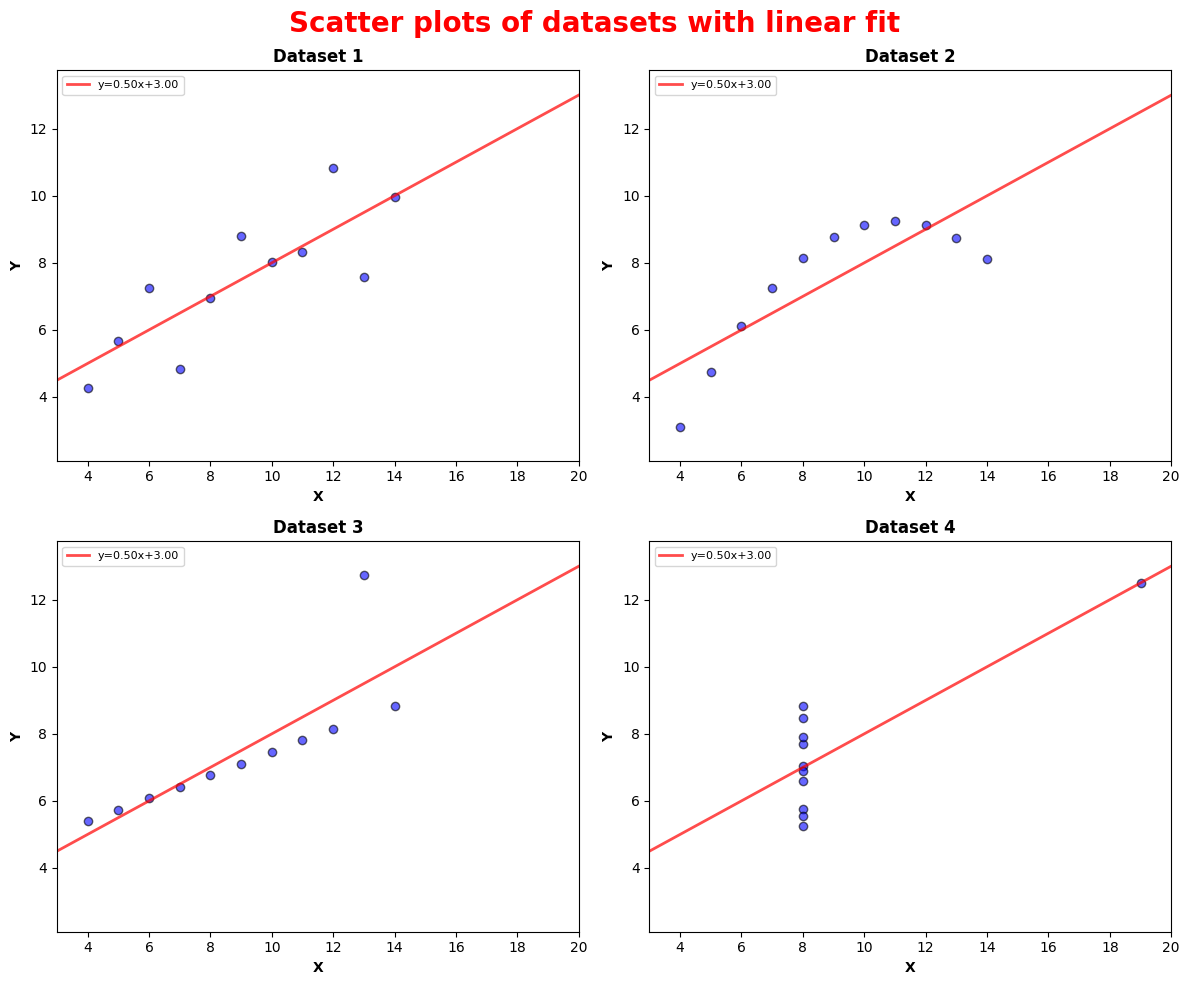

In [88]:
# plotting in a 2x2 grid with same axes limits + linear fit
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
datasets = [dataset_1, dataset_2, dataset_3, dataset_4]

# shared axis limits across all datasets
x_min = min(d[0].min() for d in datasets) - 1
x_max = max(d[0].max() for d in datasets) + 1
y_min = min(d[1].min() for d in datasets) - 1
y_max = max(d[1].max() for d in datasets) + 1

for i, (data, ax) in enumerate(zip(datasets, axes.flatten())):
    x, y = data[0], data[1]

    # scatter
    ax.scatter(x, y, color="blue", alpha=0.6, edgecolor="black")

    # linear regression fit
    fit = stats.linregress(x, y)
    x_fit = np.linspace(x_min, x_max, 200)
    y_fit = fit.slope * x_fit + fit.intercept
    ax.plot(x_fit, y_fit, color="red", linewidth=2, label=f"y={fit.slope:.2f}x+{fit.intercept:.2f}", alpha=0.7)

    ax.set_title(f"Dataset {i+1}", fontweight="bold")
    ax.set_xlabel("X", fontweight="bold")
    ax.set_ylabel("Y", fontweight="bold")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.legend(loc="upper left", fontsize=8)

fig.suptitle("Scatter plots of datasets with linear fit", fontsize=20, fontweight="bold", color="red")
plt.tight_layout()
plt.show()

## Part 4: Fundamentals of data visualization

Above, I did small introduction of data visualization. Now, we are going go through a bit more theory in the next video.

<mark>*You may feel tempted to skip the lectures on dataviz, but they are quite important. We don't have a formal book on data visualization. So the only source of knowledge about the **principles**, **theories**, and **ideas**, that are the foundation for good data viz, comes from the videos*. So **do watch them** 🤓 </mark>

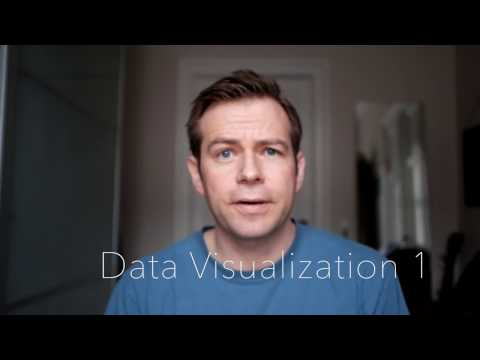

In [2]:
from IPython.display import YouTubeVideo
YouTubeVideo('yiU56codNlI', width=800, height=450)

> *Exercise 4.1:* Questions for the lecture. 
>
> * You already computed Pearson correlations for four very different datasets in Exercise 3.1. Based on that experience, give a concrete example of when Pearson correlation is misleading. Write down the mathematical formulation of the Pearson correlation and explain in your own words how it works.
>   * A concrete case where Pearson correlation is misleading is Anscombe-style data. where the datapoints have almost the same Pearson correlation but one dataset is completely different than the other when plotted. Pearson correlation measures whether (x) and (y) move together around their means, scaled by their spreads.

$r=\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}=\frac{\mathrm{cov}(X,Y)}{\sigma_X\sigma_Y}$

> * What is the difference between a bar-chart and a histogram? Can you think of a case where using one when you should use the other would lead to a wrong conclusion?
>   * In a bar chart each entry in the dataset has a bar represetnig it in the plot. In an histogram there are bins, that act as "counters" to accumulate entries with similar y values. A case where one a bar chart is not ideal it to show the height distribution of the people in a country. There a histogram would give a much better and less crowded visualization.
> * I mention in the video that it's important to choose the right bin-size in histograms. But how do you do that? Do a Google search to find a criterion you like and explain it. Then test it empirically: pick one of your crime distributions from Week 2 (e.g., time-of-day for a focus crime) and plot it as a histogram with 5, 25, and 200 bins. How does the apparent story change? Which bin count do you think is most honest?
>   * I used the  Sturges’ rule (simple and stable): $k=\lceil \log_2(n)+1 \rceil$ where (k) is number of bins and (n) is sample size.
>        - 5 bins: too coarse hides structure 
>        - 25 bins: good balance, main peaks and low-activity periods are visible without too much noise.
>        - 200 bins: too spiky and gives a too noisy plot
>   * So the most honest of the three is 25 bins (or close to the Sturges’ rule recommendation), because it preserves real patterns without over-smoothing or overfitting noise.

<div class="alert alert-block alert-info">
Answer in your own words based on the video, <b>don't use your LLM</b>. Once you've written down your answers, it's OK to use the LLM to get better. 
</div>

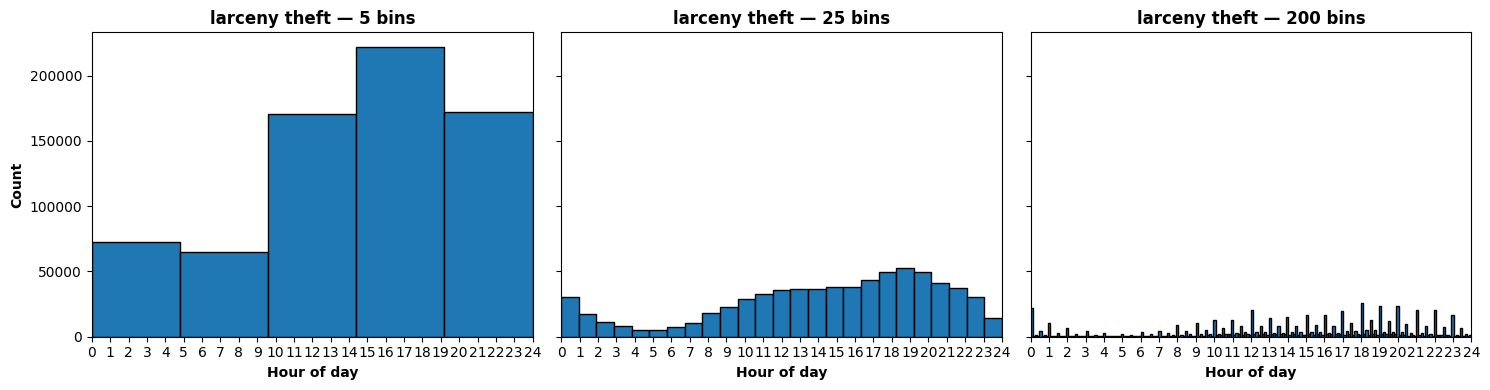

Sturges suggested bins: 21


In [96]:
crime = "larceny theft"

d = df[df["Mapped Category"].eq(crime)].copy()
dt = pd.to_datetime(d["Incident Datetime"], errors="coerce")

# decimal hour in [0, 24)
tod = dt.dt.hour + dt.dt.minute/60 + dt.dt.second/3600
tod = tod.dropna()

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, b in zip(axes, [5, 25, 200]):
    ax.hist(tod, bins=b, range=(0, 24), edgecolor="black")
    ax.set_title(f"{crime} — {b} bins", fontweight="bold")
    ax.set_xlabel("Hour of day", fontweight="bold")
    ax.set_xticks(range(0, 25, 1))
    ax.set_xlim(0, 24)
axes[0].set_ylabel("Count", fontweight="bold")
plt.tight_layout()
plt.show()

n = len(tod)
sturges_bins = int(np.ceil(np.log2(n) + 1)) if n > 1 else 1
print("Sturges suggested bins:", sturges_bins)

## Part 5: Working with 1-dimensional data

Now it's time to go deeper with visualization. We are going to read the first couple of chapters from [*Data Analysis with Open Source Tools*](http://shop.oreilly.com/product/9780596802363.do) (DAOST). It's pretty old, but I think it's a fantastic resource and one that is pretty much as relevant now as it was back then. The author is a physicist (like Sune) so he likes the way he thinks. And the books takes the reader all the way from visualization, through modeling to computational mining. Anywho - it's a great book and well worth reading in its entirety. 

As part of this class we'll be reading the first chapters. Today, we'll read chapter 2 (the first 28 pages) which supports and deepens many of the points we made during the video above. 

To find the text, you will need to go to **Teams** and have a look under the `Shared` tab. The path is `/Documents/General/DAOST_chapter2.pdf`.

> *Exercise 5.1:* Questions for DAOST 
> * Explain in your own words the point of the jitter plot.
>   * Jitter plots represent the occurences of datapoint that could overlap adding a little jitter such that the amount of overlapping points can be appreciated. 
> * Explain in your own words the point of figure 2-3. (I'm going to skip saying "in your own words" going forward, but I hope you get the point; I expect all answers to be in your own words, **not using an LLM**).
>   * Figure 2-3 shows how important is to choose the right binning anchor for histograms. The result can differ quiet a lot if the bin center is aligned on the whole number or if the bin edge is align with the number.
> * The author of DAOST (Philipp Janert) likes KDEs (and think they're better than histograms). And we don't in this class. I didn't give a detailed explanation in the video, but now that works to our advantage: You get to figure it out by yourself: When can KDEs be misleading? (Hold on to your answer — you'll test it empirically in Exercise 5.2.)
>   * KDEs can be misleading if they are too smoothed out. They can make data distribution look quiet different. 
> * I discussed some strengths of the CDF - there are also weaknesses. Janert writes "CDFs have less intuitive appeal than histograms of KDEs". What does he mean by that?
>   * CDFs are less intuitive to understand but can reveal things our eyes are not meant to understand very well. In face we percept distances way better than areas. 
> * What is a *Quantile plot*? What is it good for.     
>   * It's just a plot of a CDF where the axes have been swapped
> * How is a *Probability plot* defined? What is it useful for? Have you ever seen one before?
>   * It's a plot that compares the ordered data to the quantiles of a pre-defined distribution. If the datapoints follow that distribution they will appear on a straight line.
> * One of the reasons I like DAOST is that Janert is so suspicious of mean, median, and related summary statistics. Explain why one has to be careful when using those - and why visualization of the full data is always better (Hint: Think back on Anscombe's Quartet). 
>   * Aggregation metrics do not tell you how data is placed in the feature space while a plot can do that. Sometimes, like in the Anscombe's Quartet, summary statistics can "lie" and could lead you to the idea that the datasets are identical. But this is rarely the case. 
> * I love box plots ❤️ When are box plots most useful? 
>   * When try to visualize the distribution of different variables and identify outliers.  
> * The book doesn't mention [violin plots](https://en.wikipedia.org/wiki/Violin_plot). Are those better or worse than box plots? Why?
>   * Violin plots are better when you want to see the full distribution shape, they use KDE smoothing so there is a risk of smoothing the data too much and alter the representation.
> * Have you heard of [raincloud plots](https://wellcomeopenresearch.org/articles/4-63) or [beeswarm plots](https://python-graph-gallery.com/beeswarm/)? Look one of them up. What problem do they solve that violin plots don't?
>   * Beeswarm plot solve the problem of violin plot where datapoints are masked by the KDE. In beeswarm plot plot each point so you can directly see them. This helps preventing the hiding of the outliers effect. 
> * Remember the box-plot part [from the DataSaurus video](https://www.youtube.com/watch?v=DbJyPELmhJc) (the part that starts at 0:56)? Explain in your own words how this video illustrates potential issues even with box-plots? Do violin/bee-swarm/raincloud-plots help with that issue?
>   * Yes, as the video shows even boxplot can look very similar for those dataset that share median, quartiles and whiskers. Violin, beeswarm, and raincloud plots help partly as the reveal more of the shape of the date, so hidden structures and outliers are easier to spot. 

<div class="alert alert-block alert-info">
Answer without the help of your LLM and your goal is to learn from reading the text. but feel free to add more nuance by asking it questions.
</div>

> *Exercise 5.2:* Recreating plots from DAOST using SF crime data — Part 1
>
> * Let's make a jitter-plot (that is, code up something like **Figure 2-1** from DAOST from scratch), but based on *SF Police data*. My hunch from inspecting the file is that the police-folks might be a little bit lazy in noting down the **exact** time down to the second. So choose a crime-type and a suitable time interval (somewhere between a month and 6 months depending on the crime-type) and create a jitter plot of the arrest times during a single hour (like 13-14, for example). So let time run on the $x$-axis and create vertical jitter.
>   * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?
>       * Incidents are recorder mostly with a 10 minutes precision. I think it would be enough to look at hourly data as many points in the jitter plot cluster at :00 or :30 for each hour.
> * Last time, we did lots of bar-plots. Today, we'll play around with histograms (creating two crime-data based versions of the plot-type shown in DAOST **Figure 2-2**). I think the GPS data could be fun to see this way. 
>   * This time, pick two crime-types with different geographical patterns **and** a suitable time-interval for each (you want between 1000 and 10000 points in your histogram)
>   * Then take the latitude part of the GPS coordinates for each crime and bin the latitudes so that you have around 50 bins across the city of SF. You can use your favorite method for binning. I like `numpy.histogram`. This function gives you the counts and then you do your own plotting.
>   * Now try the same thing with longitude. Does the pattern look different? Why might the latitude and longitude distributions have different shapes for the same crime type? (Think about SF's geography — ocean on the west, bay on the east, hills in between.)
>       * Longitude and latitude are surely influenced on the city limits and geographical barriers. The two crime types likely concentrate in different parts of the city (larceny overall and assault only in specific district).
> * Next up is using the plot-type shown in **Figure 2-4** from DAOST, but with the data you used to create Figure 2.1. There is not a single great way to create kernel density plots in Python. [Here](https://www.geeksforgeeks.org/density-plots-with-pandas-in-python/), you'll find a pandas based strategy, but you can also use `gaussian_kde` from `scipy.stats` ([for an example, check out this stackoverflow post](https://stackoverflow.com/questions/4150171/how-to-create-a-density-plot-in-matplotlib)) or you can use [`seaborn.kdeplot`](https://seaborn.pydata.org/generated/seaborn.kdeplot.html). There is also another nice tutorial for KDE plots [here](https://medium.com/towards-data-science/histograms-and-density-plots-in-python-f6bda88f5ac0). Or ask your LLM what it recommends.
> * Now grab 25 random timepoints from the dataset (of 1000-10000 original data) you've just plotted and create a version of Figure 2-4 based on the 25 data points. Does this shed light on why I think KDEs can be misleading?
>   * Yes, indeed this case the effect is too smoothed due to the lack of representative points.
> * Try varying the bandwidth parameter of your KDE (e.g., make it 3x smaller and 3x larger than the default). How does the plot change? Which is more dangerous for drawing conclusions — a bandwidth that's too small (overfitting) or too large (oversmoothing)?
>   * The most dangerous is surely the 3x larger leading to oversmoothing because it hides the data distribution more. While in the overfitting I can still see the peaks clearly the oversmoothed version is "plain".

<div class="alert alert-block alert-info">
For Exercises 5.2 and 5.3, I want you to eliminate uses of LLMs where you simply cut and paste the assignments (or parts of it) into a prompt ... and ask for a solution. Instead, ask your LLM for help if you get stuck ... use it as a TA to help understand error messages ... or to help make suggestions for the right function to use ... etc. 
</div>

Let's take a break. Get some coffee or water. Stretch your legs. Talk to your friends for a bit. Breathe. Get relaxed so you're ready for the second part of the exercise. 

> *Exercise 5.3:* Recreating plots from DAOST using SF crime data — Part 2
>
> * Now we'll work on creating two versions of the plot in **Figure 2-11**, but using the GPS data you used for your version of Figure 2-2. It is not easy to create this plot from scratch.    
>   * **Hint:** Take a look at the `scipy.stats.probplot` function.
>   * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Why might the latitude distribution of crimes deviate from normal — what does the deviation tell you about the geography of crime in SF?
>       * I am comparing the data against a normal distribution so if the points would fall on the line it would mean that the data is normally distributed. This is not the case and deviation could mean that these two crimes are concentrated in specific areas of the city. 
> * OK, we're almost done, but we need some box plots. Here, I'd like you to use the box plots to visualize fluctuations of how many crimes happen per day. We'll use data from your Personal Focus Crimes (from Week 2).
>   * For the full time-span of the data, calculate the **number of crimes per day** within each category for the entire duration of the data.
>   * Create a box-and-whiskers plot showing the mean, median, quantiles, etc for all the different Personal Focus Crimes side-by-side. There are many ways to do this. I like to use [matplotlib's built in functionality](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.boxplot.html), but you can also achieve good results with [seaborn](https://seaborn.pydata.org/generated/seaborn.boxplot.html) or [pandas](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.boxplot.html). It's also fine to get help from your LLM, but make sure you check that the plot accurately shows the stats about the underlying data!
>   * What does this plot reveal that you can't see in the plots from last time?
>       * I can see how some crime categories have many outliers.
>   * Do you see outlier days? Pick one or two and look up what date they correspond to. Can you explain what happened? (Think: holidays, major events, reporting anomalies.)
>       * For assault the outliers are mostly on the beginning of the year or end/beginning of specific months. For larceny theft they are between end on June and August so this could indicate that many of these crimes are reported in the summer vacation months.
> * Also I want to show you guys another interesting use of box plots. To get started, let's calculate another average for each focus-crime, namely what time of day the crime happens. So this time, the distribution we want to plot is the average time-of-day that a crime takes place. There are many ways to do this, but let me describe one way to do it. 
>   * For datapoint, the only thing you care about is the time-of-day, so discard everything else.
>   * You also have to deal with the fact that time is annoyingly not divided into nice units that go to 100 like many other numbers. I can think of two ways to deal with this.
>     * For each time-of-day, simply encode it as seconds since midnight.
>     * Or keep each whole hour, and convert the minute/second count to a percentage of an hour. So 10:15 $\rightarrow$ 10.25, 8:40 $\rightarrow$ 8.67, etc.
> * Now you can create box-plots to create an overview of *when various crimes occur*. Note that these plots have quite a different interpretation than the ones we created in the previous exercise. Cool, right?
> * For crimes that peak late at night, does the box plot do a good job of showing the "typical" time? What goes wrong when the distribution wraps around midnight (e.g., a crime that peaks between 11pm and 1am)? Can you think of a way to handle this?
>   * Shows when each crime typically occurs as some crimes might be more frequent during the day and others at night. Crimes peaking at 23:00–01:00 will show a median near midnight but with large IQR, to solve this we could use a circular mean approach or something that takes into account the wrapping of a day.

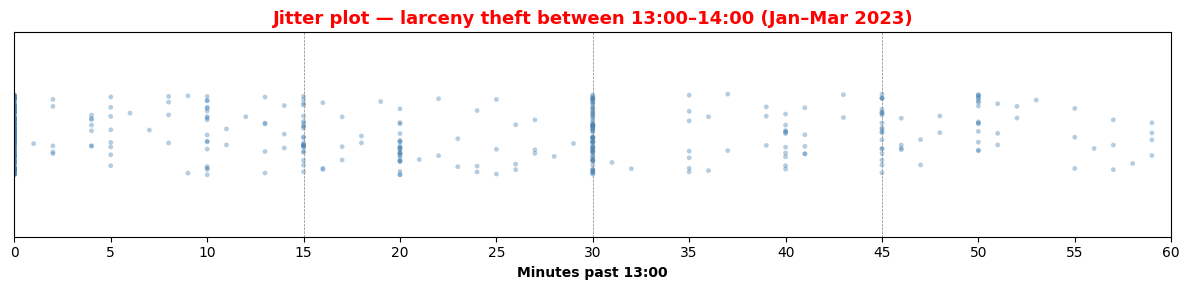

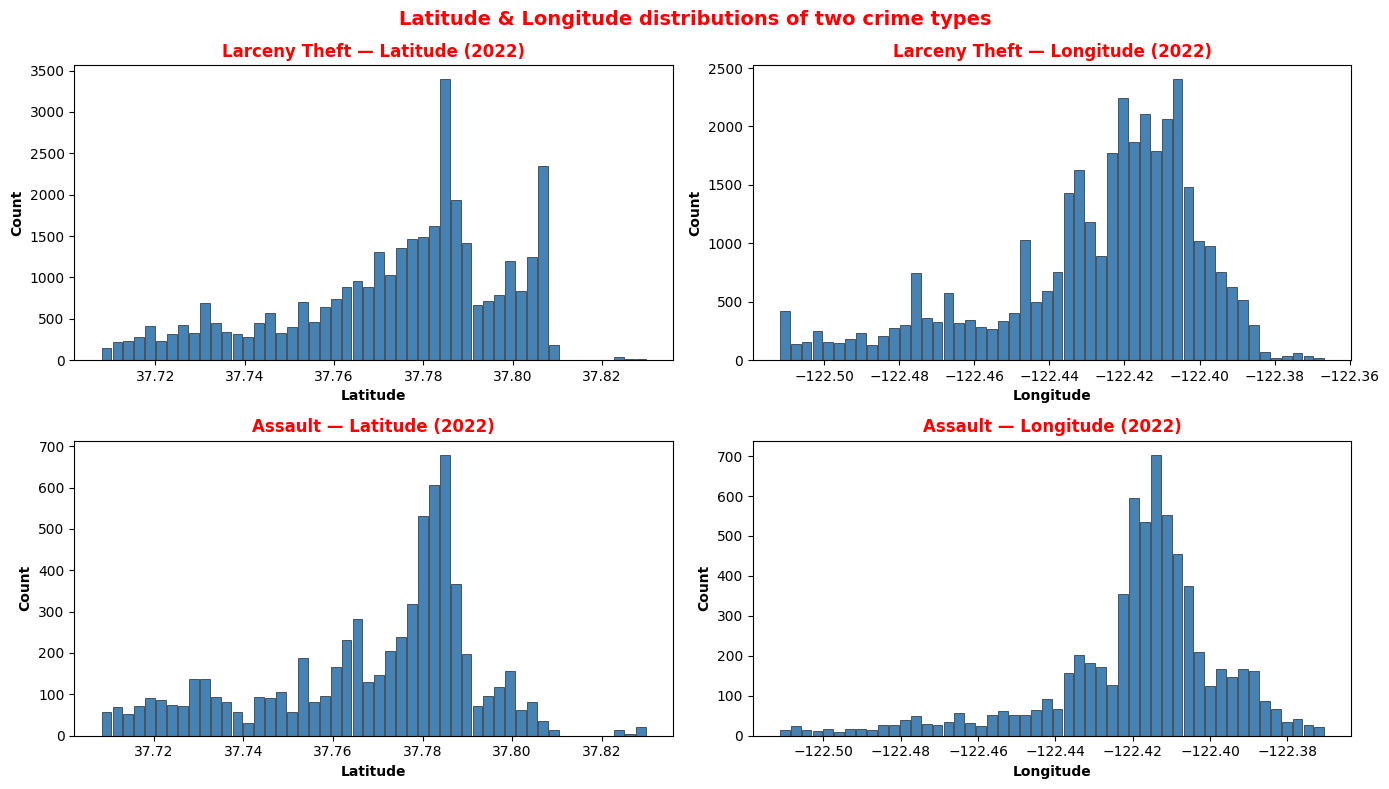

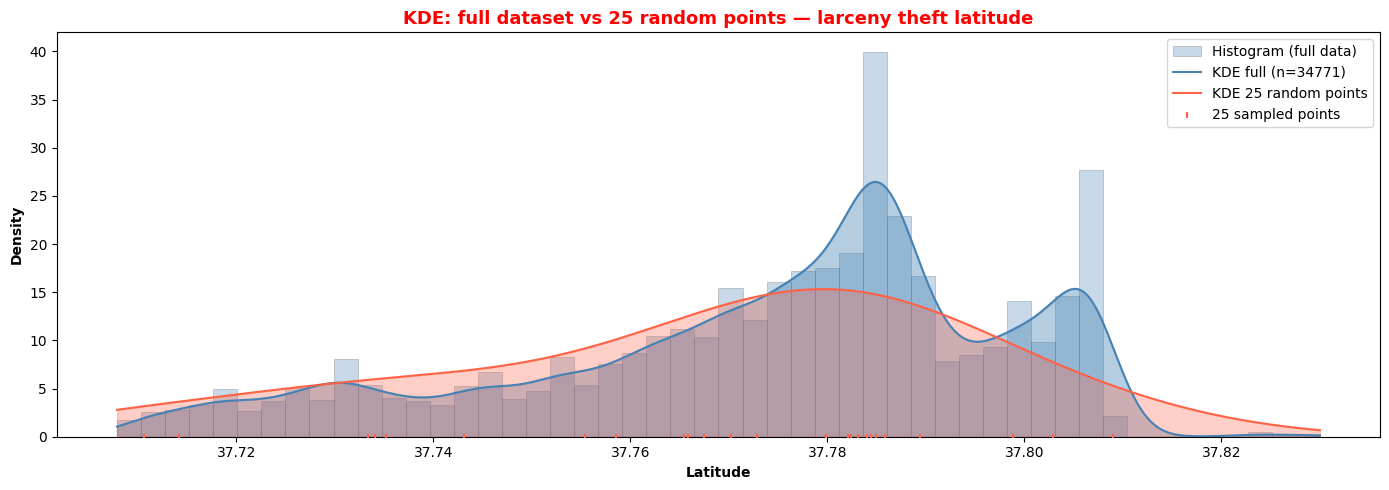

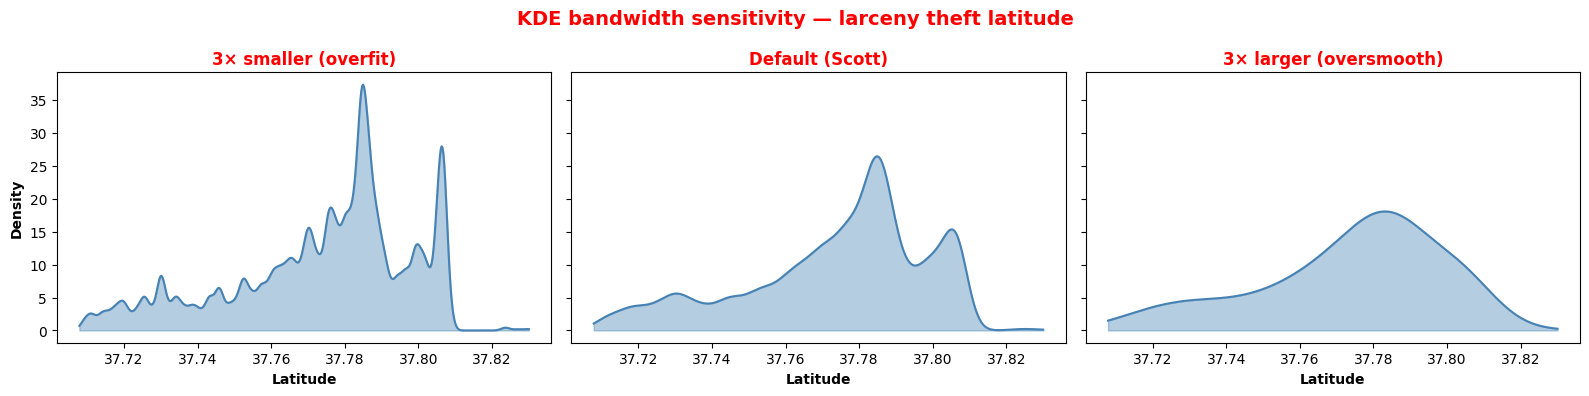

In [ ]:
# exercise 5.2

# parse point column
def parse_point(point_str):
    if pd.isna(point_str):
        return np.nan, np.nan
    match = re.match(r'POINT \(([-\d.]+) ([-\d.]+)\)', str(point_str))
    if match:
        return float(match.group(1)), float(match.group(2))
    return np.nan, np.nan

# 1 Jitter plot
crime_jitter = "larceny theft"
mask = (
    df["Mapped Category"].eq(crime_jitter)
    & df["Incident Datetime"].notna()
)
dt_jitter = pd.to_datetime(df.loc[mask, "Incident Datetime"], errors="coerce")
dt_jitter = dt_jitter[
    (dt_jitter >= "2023-01-01") & (dt_jitter < "2023-04-01")
]
dt_hour = dt_jitter[(dt_jitter.dt.hour == 13)]
minutes = dt_hour.dt.minute + dt_hour.dt.second / 60
jitter_y = np.random.uniform(-0.4, 0.4, size=len(minutes))
fig, ax = plt.subplots(figsize=(12, 3))
ax.scatter(minutes, jitter_y, alpha=0.4, s=12, color="steelblue", edgecolor="none")
ax.set_xlim(0, 60)
ax.set_ylim(-1, 1)
ax.set_xlabel("Minutes past 13:00", fontweight="bold")
ax.set_yticks([])
ax.set_xticks(range(0, 61, 5))
ax.set_title(f"Jitter plot — {crime_jitter} between 13:00–14:00 (Jan–Mar 2023)",
             fontweight="bold", fontsize=13, color="red")
for xv in [0, 15, 30, 45, 60]:
    ax.axvline(xv, color="grey", lw=0.5, ls="--")
plt.tight_layout()
plt.show()

# 2 Latitude & Longitude histograms
crime_A = "larceny theft"
crime_B = "assault"
year_range = ("2022-01-01", "2022-12-31")

def get_coords(crime, start, end):
    m = (
        df["Mapped Category"].eq(crime)
        & pd.to_datetime(df["Incident Datetime"], errors="coerce").between(start, end)
        & df["Point"].notna()
    )
    coords = df.loc[m, "Point"].apply(parse_point)
    lons = np.array([c[0] for c in coords])
    lats = np.array([c[1] for c in coords])
    valid = ~(np.isnan(lons) | np.isnan(lats))
    return lats[valid], lons[valid]

lat_A, lon_A = get_coords(crime_A, *year_range)
lat_B, lon_B = get_coords(crime_B, *year_range)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for row, (lat, lon, crime) in enumerate([(lat_A, lon_A, crime_A), (lat_B, lon_B, crime_B)]):
    for col, (vals, label) in enumerate([(lat, "Latitude"), (lon, "Longitude")]):
        ax = axes[row, col]
        counts, edges = np.histogram(vals, bins=50)
        centers = (edges[:-1] + edges[1:]) / 2
        ax.bar(centers, counts, width=(edges[1]-edges[0])*0.9,
               color="steelblue", edgecolor="black", linewidth=0.4)
        ax.set_title(f"{crime.title()} — {label} (2022)", fontweight="bold", color="red")
        ax.set_xlabel(label, fontweight="bold")
        ax.set_ylabel("Count", fontweight="bold")
plt.suptitle("Latitude & Longitude distributions of two crime types", fontsize=14,
             fontweight="bold", color="red")
plt.tight_layout()
plt.show()

# 3. KDE full dataset vs 25 random points
data_kde = lat_A
sample_25 = np.random.choice(data_kde, size=25, replace=False)
x_grid = np.linspace(lat_A.min(), lat_A.max(), 500)
kde_full = stats.gaussian_kde(data_kde)
kde_25   = stats.gaussian_kde(sample_25)
fig, ax = plt.subplots(figsize=(14, 5))
ax.hist(data_kde, bins=50, density=True, color="steelblue", edgecolor="black",
        linewidth=0.4, alpha=0.3, label="Histogram (full data)")
ax.fill_between(x_grid, kde_full(x_grid), alpha=0.4, color="steelblue")
ax.plot(x_grid, kde_full(x_grid), color="steelblue", lw=1.5,
        label=f"KDE full (n={len(data_kde)})")
ax.fill_between(x_grid, kde_25(x_grid), alpha=0.3, color="tomato")
ax.plot(x_grid, kde_25(x_grid), color="tomato", lw=1.5,
        label="KDE 25 random points")
ax.scatter(sample_25, np.zeros(25), color="tomato", s=20, zorder=5,
           marker="|", linewidths=1.5, label="25 sampled points")
ax.set_title(f"KDE: full dataset vs 25 random points — {crime_A} latitude",
             fontweight="bold", fontsize=13, color="red")
ax.set_xlabel("Latitude", fontweight="bold")
ax.set_ylabel("Density", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

# 4 Bandwidth sensitivity
bw_default = kde_full.factor
bw_small   = bw_default / 3
bw_large   = bw_default * 3

fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)
for ax, bw_scale, label in zip(
    axes,
    [bw_small, bw_default, bw_large],
    ["3× smaller (overfit)", "Default (Scott)", "3× larger (oversmooth)"]
):
    kde_bw = stats.gaussian_kde(data_kde, bw_method=bw_scale)
    ax.fill_between(x_grid, kde_bw(x_grid), alpha=0.4, color="steelblue")
    ax.plot(x_grid, kde_bw(x_grid), color="steelblue", lw=1.5)
    ax.set_title(label, fontweight="bold", color="red")
    ax.set_xlabel("Latitude", fontweight="bold")
axes[0].set_ylabel("Density", fontweight="bold")
plt.suptitle(f"KDE bandwidth sensitivity — {crime_A} latitude", fontsize=14, fontweight="bold", color="red")
plt.tight_layout()
plt.show()

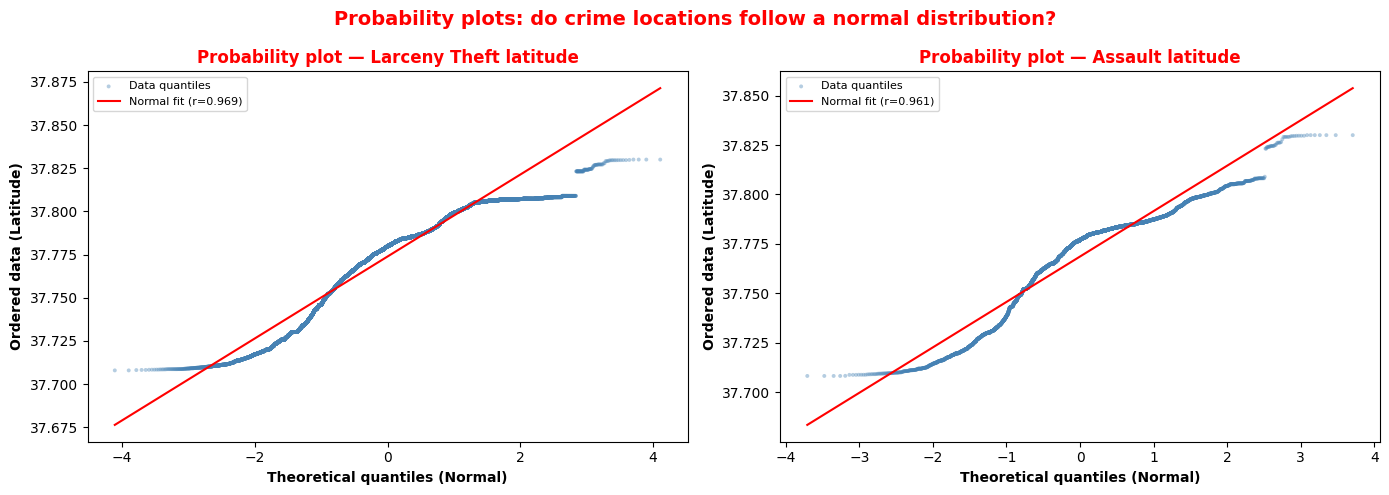

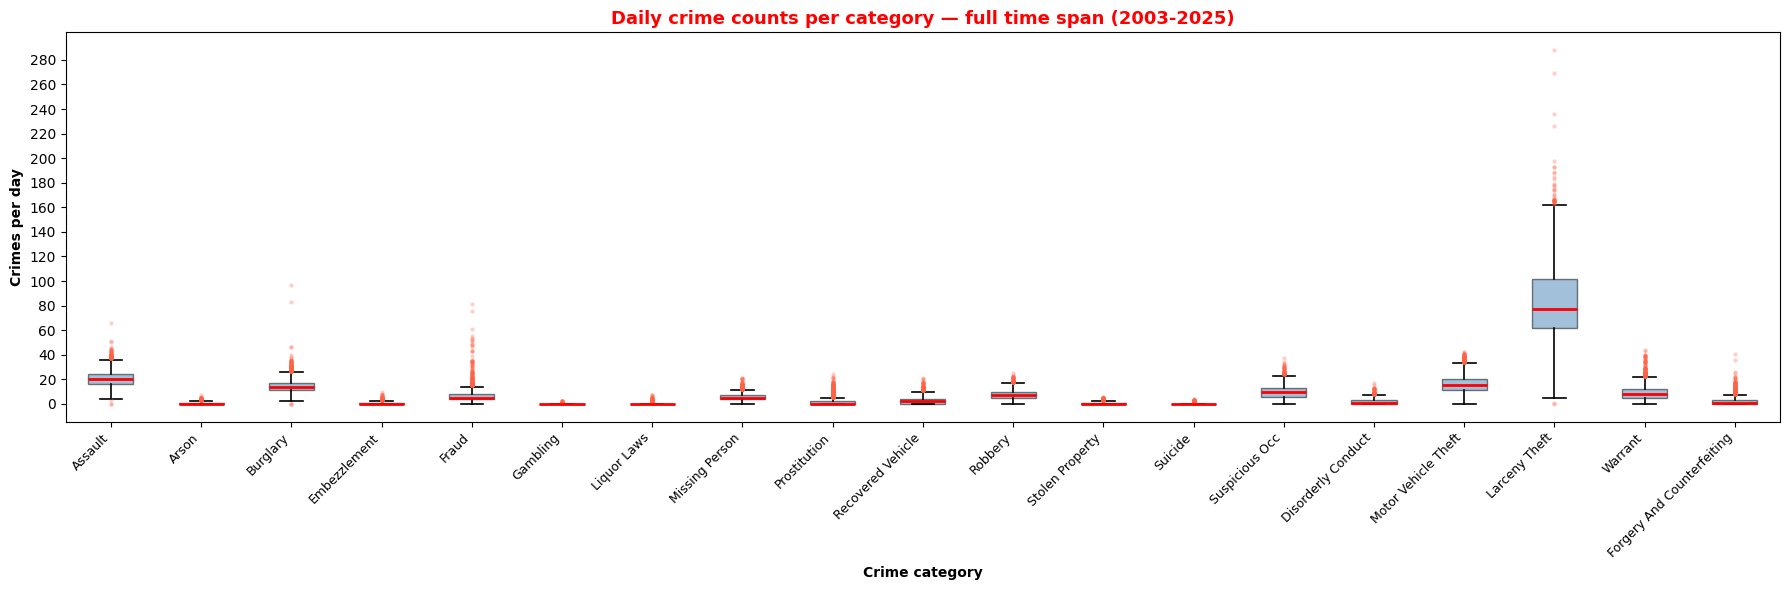

Top 5 outlier days for 'larceny theft':
Date
2022-06-26    288
2023-06-25    269
2023-08-12    236
2019-06-30    226
2017-06-25    198
Name: larceny theft, dtype: int64
Top 5 outlier days for 'assault':
Date
2003-01-01    66
2008-01-01    51
2009-11-01    50
2004-10-31    46
2003-03-20    45
Name: assault, dtype: int64


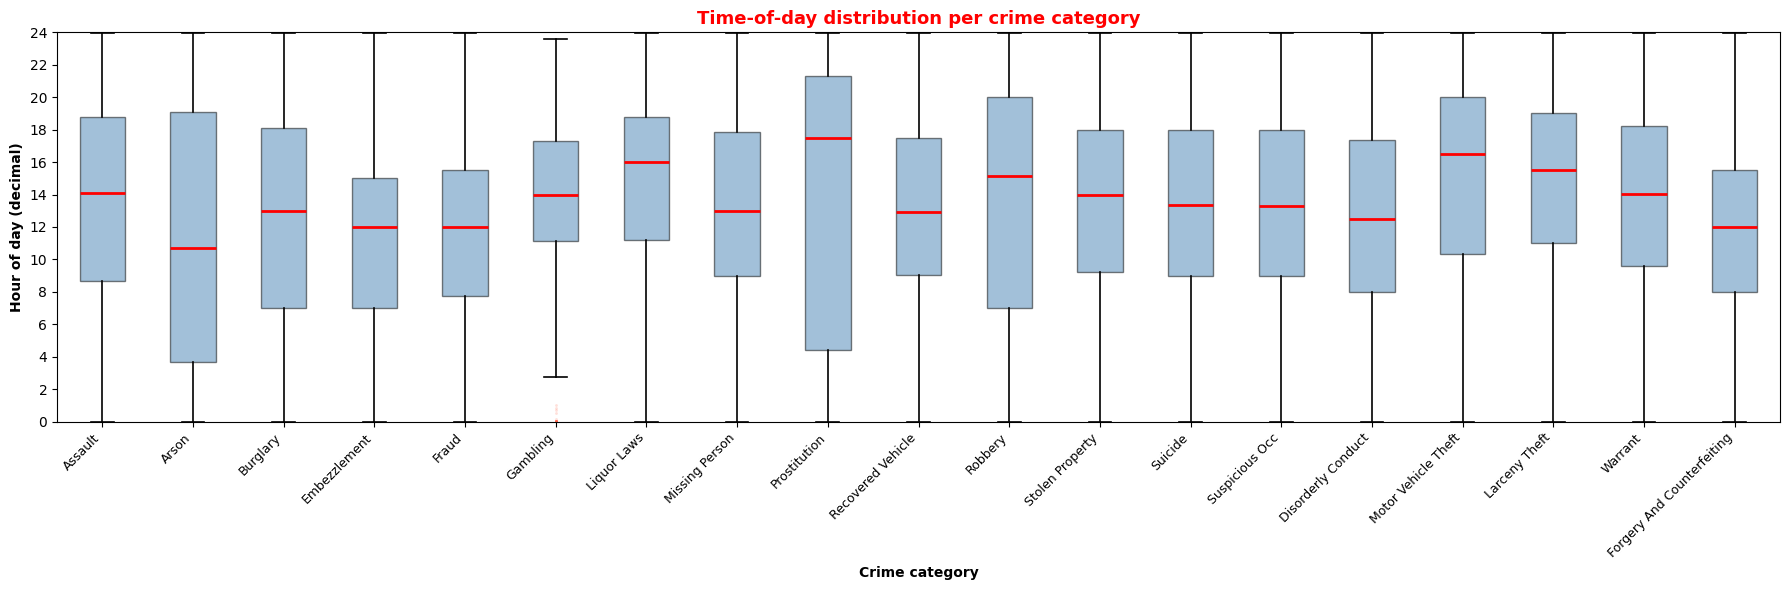

In [113]:
# exercise 5.3

# 1 Probability plots 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, lat, crime in [(axes[0], lat_A, crime_A), (axes[1], lat_B, crime_B)]:
    (osm, osr), (slope, intercept, r) = stats.probplot(lat, dist="norm")
    ax.scatter(osm, osr, color="steelblue", alpha=0.4, s=8, edgecolor="none",
               label="Data quantiles")
    x_line = np.array([osm.min(), osm.max()])
    ax.plot(x_line, slope * x_line + intercept, color="red", lw=1.5,
            label=f"Normal fit (r={r:.3f})")
    ax.set_title(f"Probability plot — {crime.title()} latitude",
                 fontweight="bold", color="red")
    ax.set_xlabel("Theoretical quantiles (Normal)", fontweight="bold")
    ax.set_ylabel("Ordered data (Latitude)", fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("Probability plots: do crime locations follow a normal distribution?",
             fontsize=14, fontweight="bold", color="red")
plt.tight_layout()
plt.show()

# 2 Box plots crimes per day
df_focus = df[
    df["Mapped Category"].isin(FOCUS_CRIMES_MINUS_NONCRIMINAL)
    & df["Incident Datetime"].notna()
].copy()
df_focus["Date"] = pd.to_datetime(df_focus["Incident Datetime"], errors="coerce").dt.date
daily_counts = (
    df_focus.groupby(["Date", "Mapped Category"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=FOCUS_CRIMES_MINUS_NONCRIMINAL, fill_value=0)
)
# collect data per crime as list of arrays
data_per_crime = [daily_counts[crime].values for crime in FOCUS_CRIMES_MINUS_NONCRIMINAL]
fig, ax = plt.subplots(figsize=(18, 6))
bp = ax.boxplot(data_per_crime, patch_artist=True, notch=False,
                medianprops=dict(color="red", lw=2),
                boxprops=dict(facecolor="steelblue", alpha=0.5),
                flierprops=dict(marker="o", markersize=3, alpha=0.3,
                                markerfacecolor="tomato", markeredgecolor="none"),
                whiskerprops=dict(lw=1.2),
                capprops=dict(lw=1.2))
ax.set_xticks(range(1, len(FOCUS_CRIMES_MINUS_NONCRIMINAL) + 1))
ax.set_yticks(range(0, daily_counts.values.max() + 1, 20))
ax.set_xticklabels([c.title() for c in FOCUS_CRIMES_MINUS_NONCRIMINAL],
                   rotation=45, ha="right", fontsize=9)
ax.set_ylabel("Crimes per day", fontweight="bold")
ax.set_xlabel("Crime category", fontweight="bold")
ax.set_title("Daily crime counts per category — full time span (2003-2025)",
             fontweight="bold", fontsize=13, color="red")
plt.tight_layout()
plt.show()
# print top outlier days for larceny theft
crime_check = "larceny theft"
outlier_days = daily_counts[crime_check].nlargest(5)
print(f"Top 5 outlier days for '{crime_check}':")
print(outlier_days)
# print top outlier days for assault
crime_check = "assault"
outlier_days = daily_counts[crime_check].nlargest(5)
print(f"Top 5 outlier days for '{crime_check}':")
print(outlier_days)

# 3 Box plots time of day per crime
df_focus["TOD"] = (
    pd.to_datetime(df_focus["Incident Datetime"], errors="coerce")
    .apply(lambda t: t.hour + t.minute / 60 + t.second / 3600 if pd.notna(t) else np.nan)
)
tod_per_crime = [
    df_focus.loc[df_focus["Mapped Category"] == crime, "TOD"].dropna().values
    for crime in FOCUS_CRIMES_MINUS_NONCRIMINAL
]
fig, ax = plt.subplots(figsize=(18, 6))
bp2 = ax.boxplot(tod_per_crime, patch_artist=True, notch=False,
                 medianprops=dict(color="red", lw=2),
                 boxprops=dict(facecolor="steelblue", alpha=0.5),
                 flierprops=dict(marker="o", markersize=2, alpha=0.2,
                                 markerfacecolor="tomato", markeredgecolor="none"),
                 whiskerprops=dict(lw=1.2),
                 capprops=dict(lw=1.2))
ax.set_xticks(range(1, len(FOCUS_CRIMES_MINUS_NONCRIMINAL) + 1))
ax.set_xticklabels([c.title() for c in FOCUS_CRIMES_MINUS_NONCRIMINAL],
                   rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(0, 25, 2))
ax.set_ylim(0, 24)
ax.set_ylabel("Hour of day (decimal)", fontweight="bold")
ax.set_xlabel("Crime category", fontweight="bold")
ax.set_title("Time-of-day distribution per crime category",
             fontweight="bold", fontsize=13, color="red")
plt.tight_layout()
plt.show()

---

## You've Completed Week 3!

This week you went deeper into both data analysis and visualization theory. You now have:

- Experience with conditional plots — comparing crime profiles across districts and over time
- A deeper understanding (via Anscombe's quartet) of why you should always plot your data
- Familiarity with a range of visualization types: jitter plots, histograms, KDEs, probability plots, box plots, and violin plots
- A foundation in visualization theory from the lectures and DAOST Chapter 2

**Key takeaways:**
- Summary statistics can hide important structure in data. Always visualize.
- Conditional probabilities (like `P(crime|district)/P(crime)`) are a simple but powerful tool for finding patterns.
- Crime patterns aren't static — neighborhoods change, and models trained on old data can become misleading.
- Different plot types reveal different aspects of the same data. Choosing the right one matters.

If you want to go further:
- Try creating violin or swarm plots as alternatives to the box plots from Exercise 5.3 — do they reveal anything the box plots missed?
- Explore whether the time-of-day patterns differ between districts (combining the ideas from Parts 2 and 5)